#  E-Commerce Customer Churn Prediction
**Student:** Romaisaa Mohamed  22100583
**Dataset:** E-Commerce Customer Churn Dataset  
**Goal:** Predict whether a customer will churn (leave the platform) based on their behavior and demographics.

---
## Section 1: Problem Statement

### Research Questions:
1. **Can we predict whether an e-commerce customer will churn?**
2. Which customer behaviors and demographics are the strongest indicators of churn?
3. Can we identify at-risk customers early so the business can retain them?

### Why this matters:
Acquiring a new customer costs 5–7x more than retaining an existing one. 
By predicting churn in advance, the business can proactively offer discounts or improve service for at-risk customers.

---
##  Section 2: Import Libraries

In [6]:
# ── Standard libraries ──
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── Visualization ──
import matplotlib.pyplot as plt
import seaborn as sns

# ── Preprocessing ──
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score

# ── Feature Selection ──
from sklearn.feature_selection import SelectKBest, chi2, f_classif

# ── Models ──
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# ── Evaluation ──
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve
)

# ── Save model ──
import joblib

print('All libraries imported successfully!')

All libraries imported successfully!


---
##  Section 3: Load Dataset

In [17]:
df = pd.read_excel('E Commerce.xlsx', sheet_name='E Comm')

print(f'Dataset shape: {df.shape}')
print(f'\nColumn names:')
print(df.columns.tolist())

Dataset shape: (5630, 20)

Column names:
['CustomerID', 'Churn', 'Tenure', 'PreferredLoginDevice', 'CityTier', 'WarehouseToHome', 'PreferredPaymentMode', 'Gender', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore', 'MaritalStatus', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']


In [18]:
# Preview first 5 rows
df.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


In [19]:
# Basic info — data types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   str    
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   str    
 7   Gender                       5630 non-null   str    
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   str    
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   str    
 13  NumberOfAddress              

In [20]:
# Statistical summary of numeric columns
df.describe()

,CustomerID,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
count,5630.000000,5630.000000,5366.000000,5630.000000,5379.000000,5375.000000,5630.000000,5630.000000,5630.000000,5630.000000,5365.000000,5374.000000,5372.000000,5323.000000,5630.000000
mean,52815.500000,0.168384,10.189899,1.654707,15.639896,2.931535,3.688988,3.066785,4.214032,0.284902,15.707922,1.751023,3.008004,4.543491,177.223030
std,1625.385339,0.374240,8.557241,0.915389,8.531475,0.721926,1.023999,1.380194,2.583586,0.451408,3.675485,1.894621,2.939680,3.654433,49.207036
min,50001.000000,0.000000,0.000000,1.000000,5.000000,0.000000,1.000000,1.000000,1.000000,0.000000,11.000000,0.000000,1.000000,0.000000,0.000000
25%,51408.250000,0.000000,2.000000,1.000000,9.000000,2.000000,3.000000,2.000000,2.000000,0.000000,13.000000,1.000000,1.000000,2.000000,145.770000
50%,52815.500000,0.000000,9.000000,1.000000,14.000000,3.000000,4.000000,3.000000,3.000000,0.000000,15.000000,1.000000,2.000000,3.000000,163.280000
75%,54222.750000,0.000000,16.000000,3.000000,20.000000,3.000000,4.000000,4.000000,6.000000,1.000000,18.000000,2.000000,3.000000,7.000000,196.392500
max,55630.000000,1.000000,61.000000,3.000000,127.000000,5.000000,6.000000,5.000000,22.000000,1.000000,26.000000,16.000000,16.000000,46.000000,324.990000


---
##  Section 4: Data Cleaning

This section documents every change made to clean the raw data.

In [21]:
# ── Step 4.1: Check for missing values ──
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).query('`Missing Count` > 0').sort_values('Missing %', ascending=False)

print('Columns with missing values:')
print(missing_df)

Columns with missing values:
                             Missing Count  Missing %
DaySinceLastOrder                      307   5.452931
OrderAmountHikeFromlastYear            265   4.706927
Tenure                                 264   4.689165
OrderCount                             258   4.582593
CouponUsed                             256   4.547069
HourSpendOnApp                         255   4.529307
WarehouseToHome                        251   4.458259


In [22]:
# ── Step 4.2: Handle missing values ──
# For numeric columns → fill with median (robust to outliers)
# For categorical columns → fill with mode (most frequent value)

def fill_missing_values(dataframe):
    """Fill missing values: median for numeric, mode for categorical."""
    df_clean = dataframe.copy()
    
    for col in df_clean.columns:
        if df_clean[col].isnull().sum() > 0:
            if df_clean[col].dtype in ['float64', 'int64']:
                median_val = df_clean[col].median()
                df_clean[col].fillna(median_val, inplace=True)
                print(f'   {col}: filled {dataframe[col].isnull().sum()} nulls with median ({median_val:.2f})')
            else:
                mode_val = df_clean[col].mode()[0]
                df_clean[col].fillna(mode_val, inplace=True)
                print(f'  {col}: filled {dataframe[col].isnull().sum()} nulls with mode ("{mode_val}")')
    
    return df_clean

print('Filling missing values...')
df = fill_missing_values(df)
print(f'\nMissing values remaining: {df.isnull().sum().sum()}')

Filling missing values...
   Tenure: filled 264 nulls with median (9.00)
   WarehouseToHome: filled 251 nulls with median (14.00)
   HourSpendOnApp: filled 255 nulls with median (3.00)
   OrderAmountHikeFromlastYear: filled 265 nulls with median (15.00)
   CouponUsed: filled 256 nulls with median (1.00)
   OrderCount: filled 258 nulls with median (2.00)
   DaySinceLastOrder: filled 307 nulls with median (3.00)

Missing values remaining: 1856


In [23]:
# ── Step 4.3: Check for duplicate rows ──
duplicate_count = df.duplicated().sum()
print(f'Duplicate rows found: {duplicate_count}')

if duplicate_count > 0:
    df.drop_duplicates(inplace=True)
    print(f' Duplicates removed. New shape: {df.shape}')

Duplicate rows found: 0


In [24]:
# ── Step 4.4: Fix data types ──
# CustomerID should not be used for modeling — drop it
if 'CustomerID' in df.columns:
    df.drop(columns=['CustomerID'], inplace=True)
    print(' Dropped CustomerID column (not useful for prediction)')

print(f'\nFinal cleaned shape: {df.shape}')

 Dropped CustomerID column (not useful for prediction)

Final cleaned shape: (5630, 19)


In [25]:
# ── Step 4.5: Check class balance of target variable ──
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print('Target variable distribution:')
print(pd.DataFrame({'Count': churn_counts, 'Percentage': churn_pct.round(2)}))

Target variable distribution:
       Count  Percentage
Churn                   
0       4682       83.16
1        948       16.84


---
##  Section 5: Exploratory Data Analysis (EDA)

We investigate our research questions from multiple angles using both univariate (one variable) and bivariate (two variables) analysis.

In [26]:
# Helper function to set a consistent plot style
def set_plot_style():
    """Apply a clean visual style to all plots."""
    sns.set_style('whitegrid')
    plt.rcParams['figure.figsize'] = (10, 5)
    plt.rcParams['font.size'] = 12

set_plot_style()

### 5.1 Univariate Analysis — Target Variable

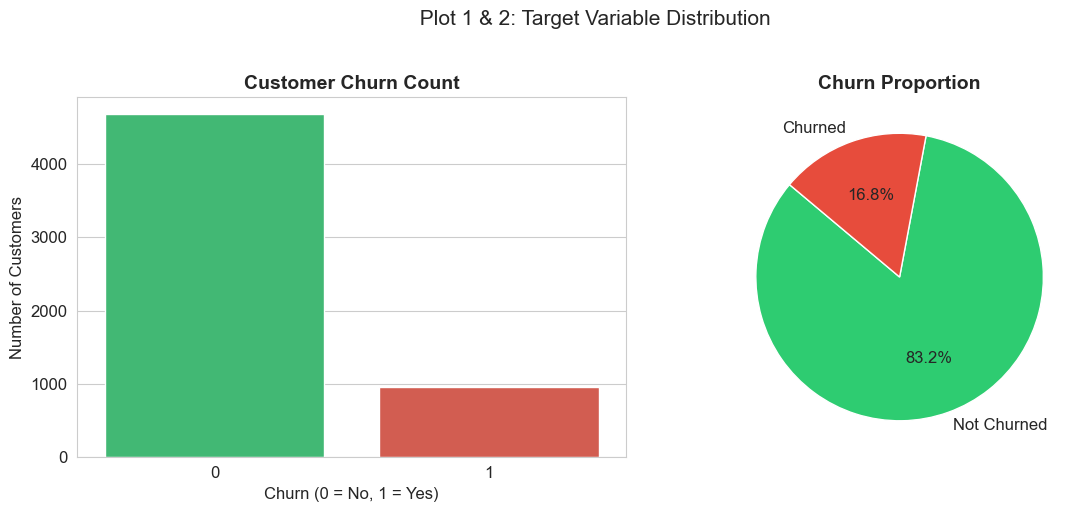

Observation: The dataset is imbalanced — churned customers are the minority class.


In [27]:
# Plot 1: Bar chart — Churn distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
sns.countplot(x='Churn', data=df, palette=['#2ecc71', '#e74c3c'], ax=axes[0])
axes[0].set_title('Customer Churn Count', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Churn (0 = No, 1 = Yes)')
axes[0].set_ylabel('Number of Customers')

# Pie chart
churn_counts = df['Churn'].value_counts()
axes[1].pie(churn_counts, labels=['Not Churned', 'Churned'],
            colors=['#2ecc71', '#e74c3c'], autopct='%1.1f%%', startangle=140)
axes[1].set_title('Churn Proportion', fontsize=14, fontweight='bold')

plt.suptitle(' Plot 1 & 2: Target Variable Distribution', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

print('Observation: The dataset is imbalanced — churned customers are the minority class.')

### 5.2 Univariate Analysis — Numeric Variables

In [28]:
# Identify numeric and categorical columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# Remove target from numeric list for feature analysis
numeric_features = [col for col in numeric_cols if col != 'Churn']

print('Numeric features:', numeric_features)
print('Categorical features:', categorical_cols)

Numeric features: ['Tenure', 'CityTier', 'WarehouseToHome', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']
Categorical features: ['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender', 'PreferedOrderCat', 'MaritalStatus']


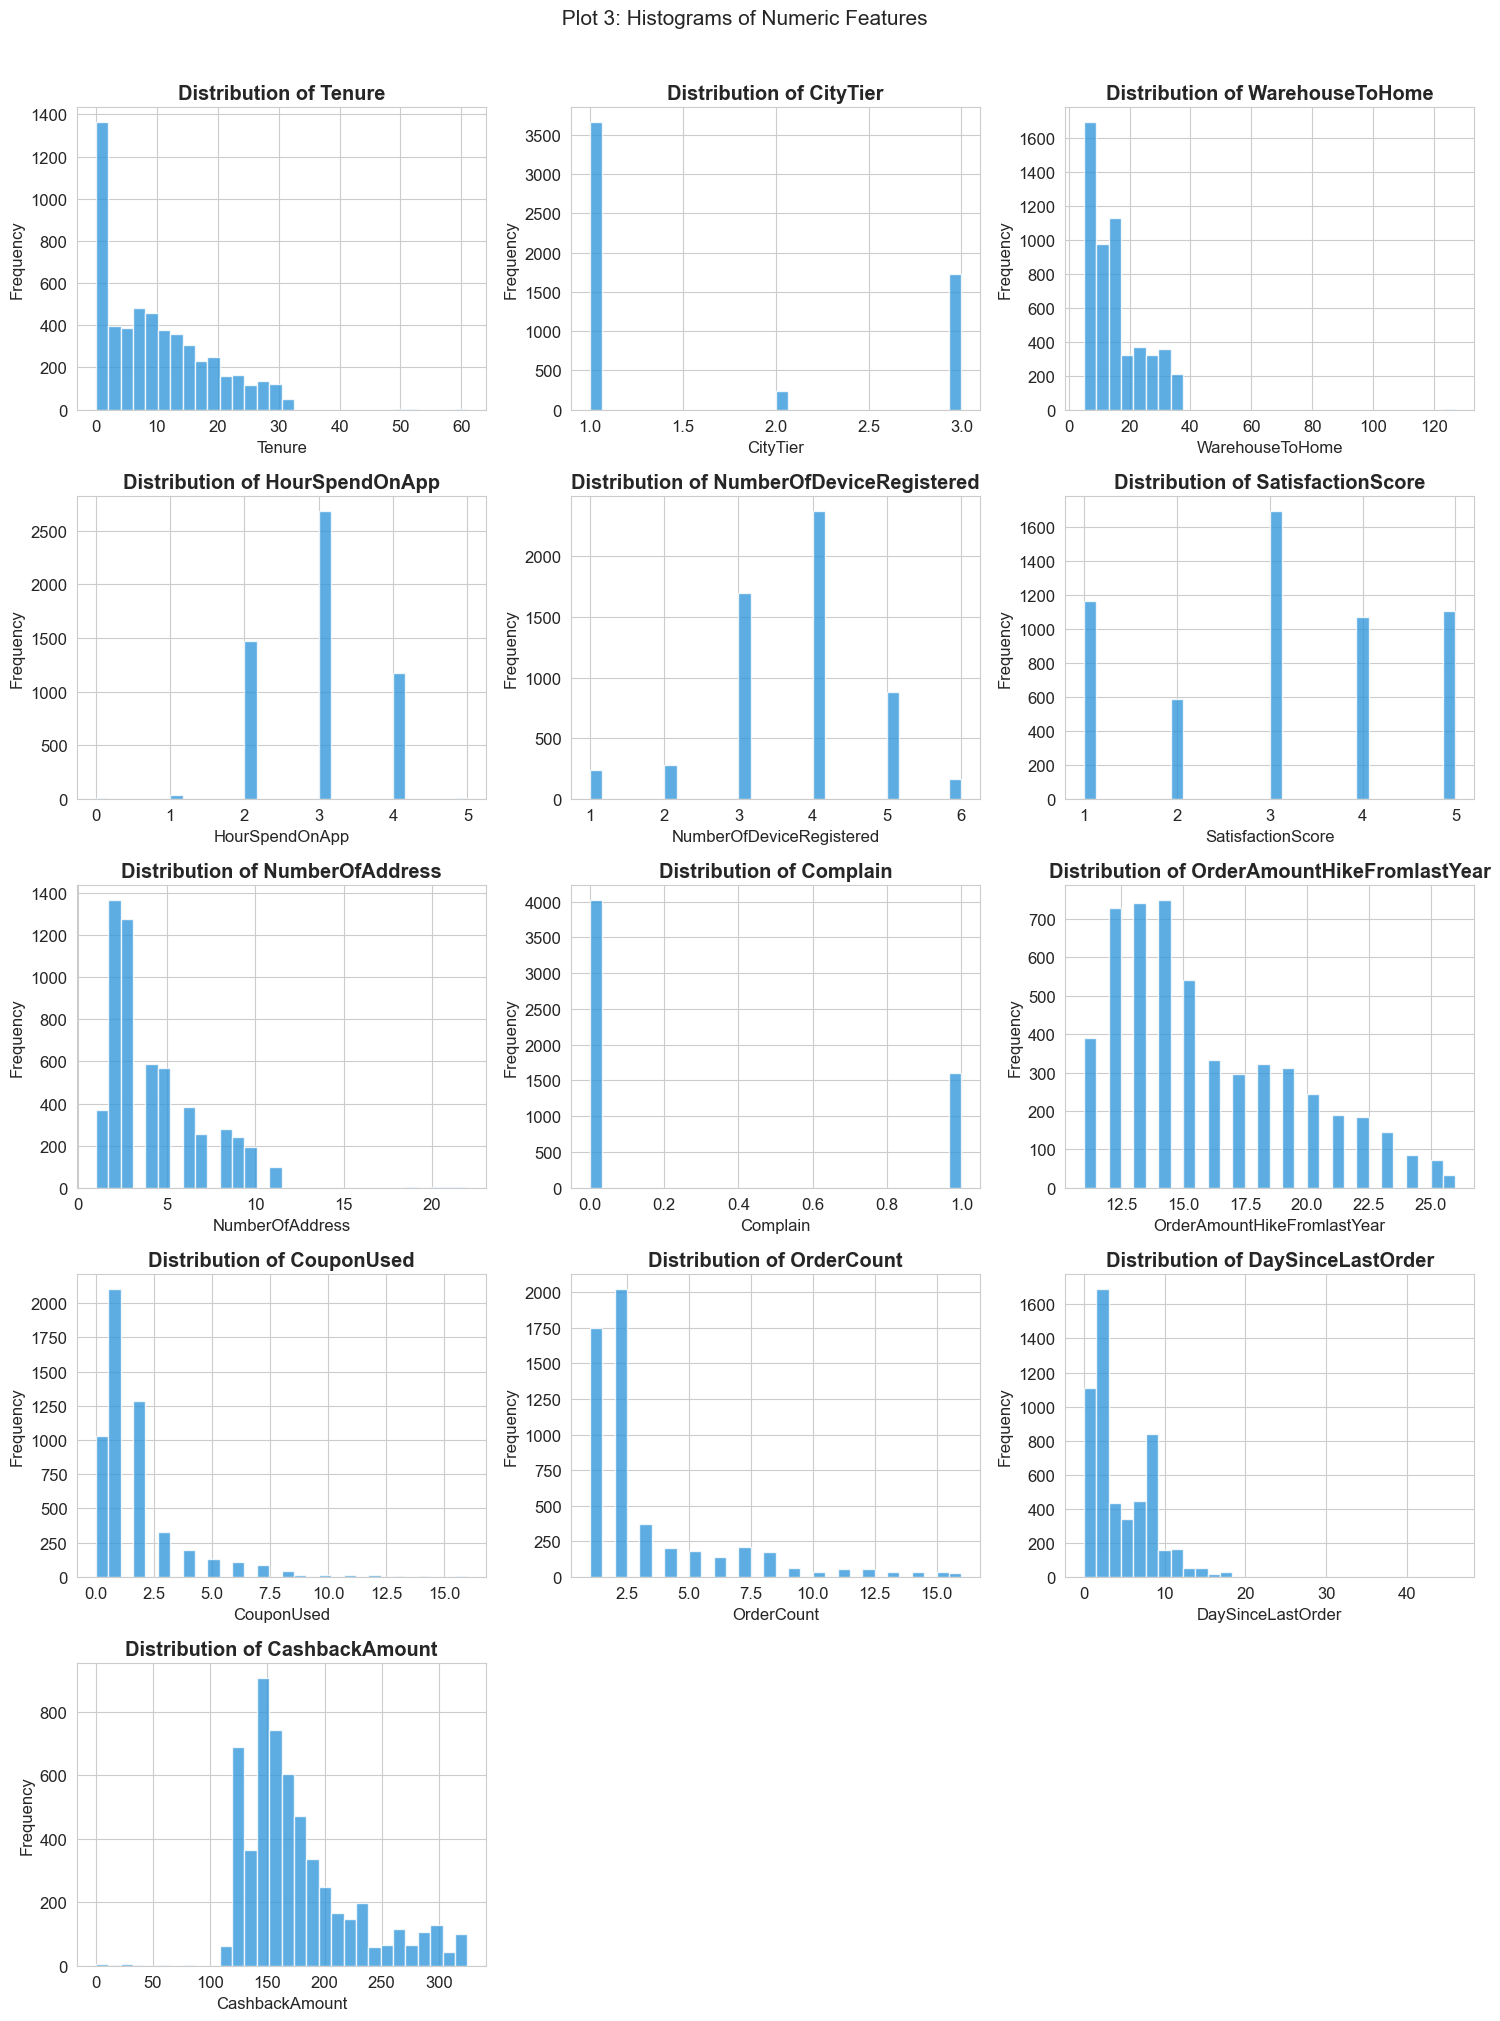

In [29]:
# Plot 3: Histograms for numeric features
n_cols = 3
n_rows = (len(numeric_features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    axes[i].hist(df[col], bins=30, color='#3498db', edgecolor='white', alpha=0.8)
    axes[i].set_title(f'Distribution of {col}', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# Hide empty subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(' Plot 3: Histograms of Numeric Features', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

### 5.3 Bivariate Analysis — Numeric Features vs Churn

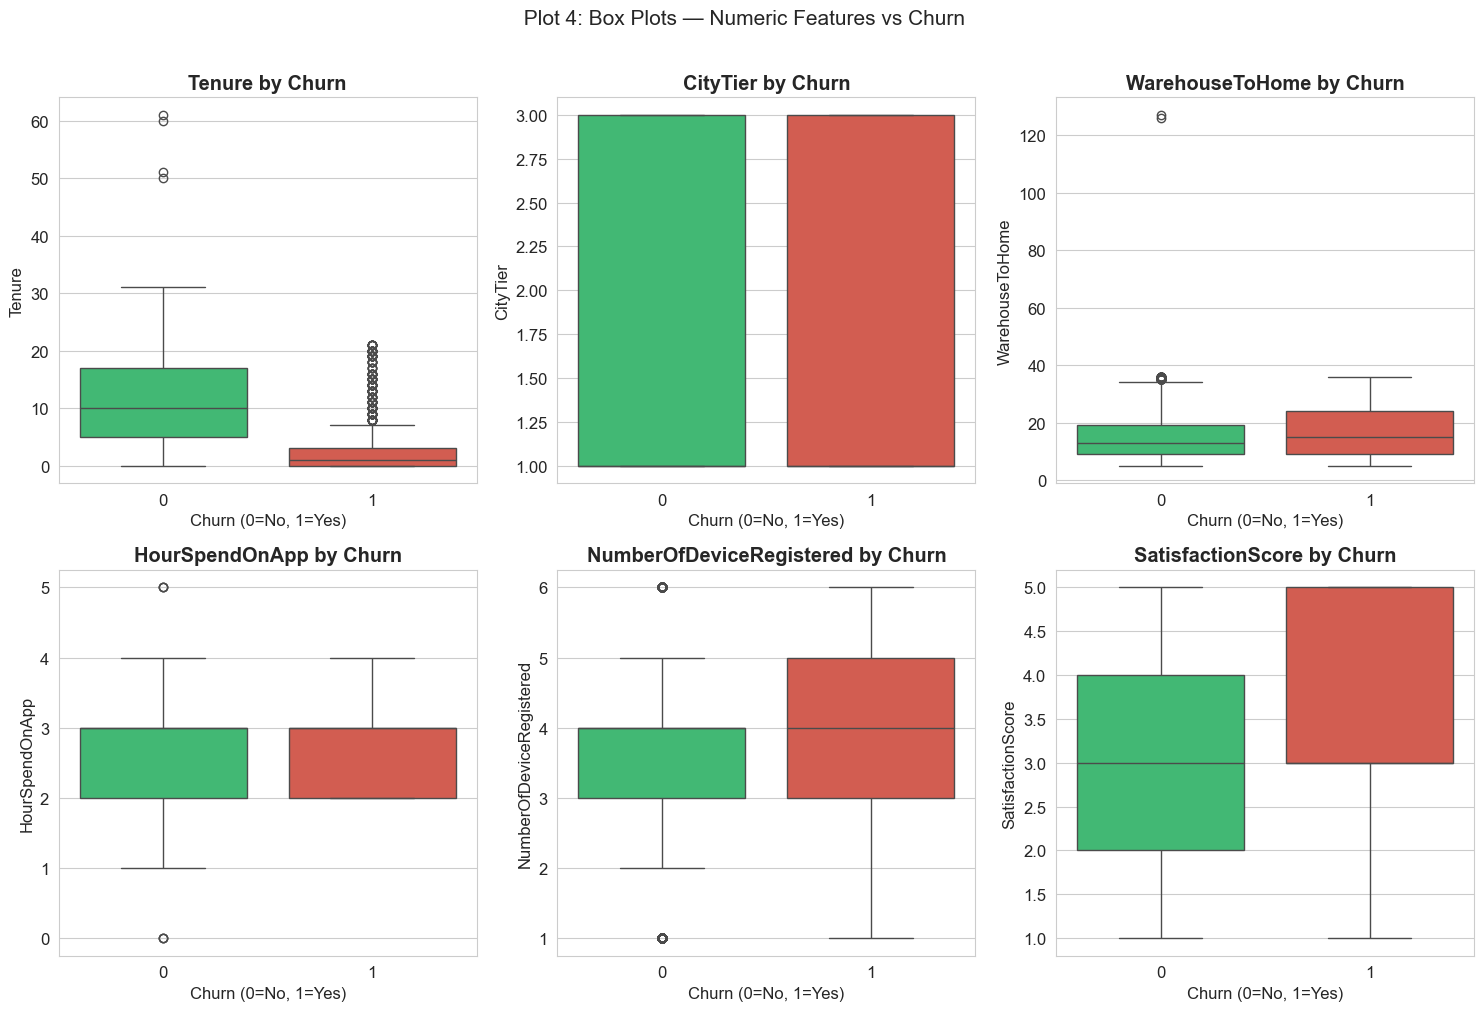

Observation: Look for features where the boxes are clearly different between churned and non-churned customers — these will be important predictors.


In [30]:
# Plot 4: Box plots — Numeric features by Churn
key_numeric = numeric_features[:6]  # Show top 6 for clarity

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(key_numeric):
    sns.boxplot(x='Churn', y=col, data=df,
                palette=['#2ecc71', '#e74c3c'], ax=axes[i])
    axes[i].set_title(f'{col} by Churn', fontweight='bold')
    axes[i].set_xlabel('Churn (0=No, 1=Yes)')

plt.suptitle(' Plot 4: Box Plots — Numeric Features vs Churn', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

print('Observation: Look for features where the boxes are clearly different between churned and non-churned customers — these will be important predictors.')

In [31]:
# Statistical summary: mean of each feature grouped by churn
print('Mean values per group (Churn = 0 vs 1):')
df.groupby('Churn')[numeric_features].mean().T.round(2)

Mean values per group (Churn = 0 vs 1):


Churn,0,1
Tenure,11.50,3.38
CityTier,1.62,1.83
WarehouseToHome,15.35,17.13
HourSpendOnApp,2.93,2.96
NumberOfDeviceRegistered,3.64,3.93
SatisfactionScore,3.00,3.39
NumberOfAddress,4.16,4.47
Complain,0.23,0.54
OrderAmountHikeFromlastYear,15.72,15.63
CouponUsed,1.76,1.72


### 5.4 Bivariate Analysis — Categorical Features vs Churn

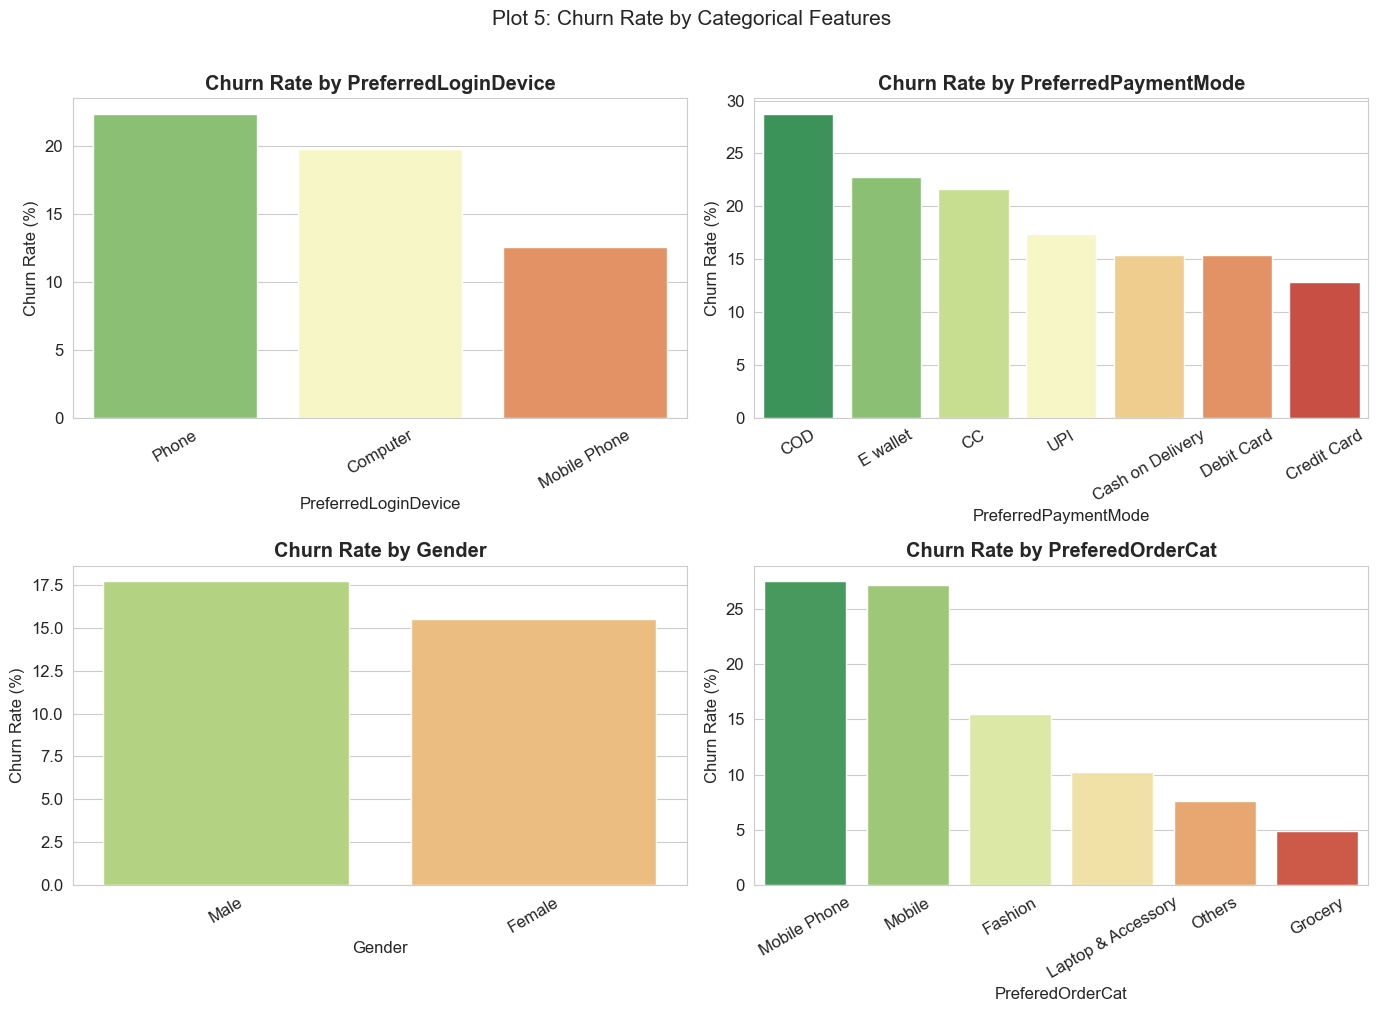

In [32]:
# Plot 5: Grouped bar charts — Categorical features vs Churn
key_cat = categorical_cols[:4]  # Show top 4 categorical features

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(key_cat):
    # Calculate churn rate per category
    churn_rate = df.groupby(col)['Churn'].mean().reset_index()
    churn_rate.columns = [col, 'Churn Rate']
    churn_rate['Churn Rate'] = churn_rate['Churn Rate'] * 100
    churn_rate = churn_rate.sort_values('Churn Rate', ascending=False)
    
    sns.barplot(x=col, y='Churn Rate', data=churn_rate,
                palette='RdYlGn_r', ax=axes[i])
    axes[i].set_title(f'Churn Rate by {col}', fontweight='bold')
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].tick_params(axis='x', rotation=30)

plt.suptitle('Plot 5: Churn Rate by Categorical Features', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

### 5.5 Correlation Analysis

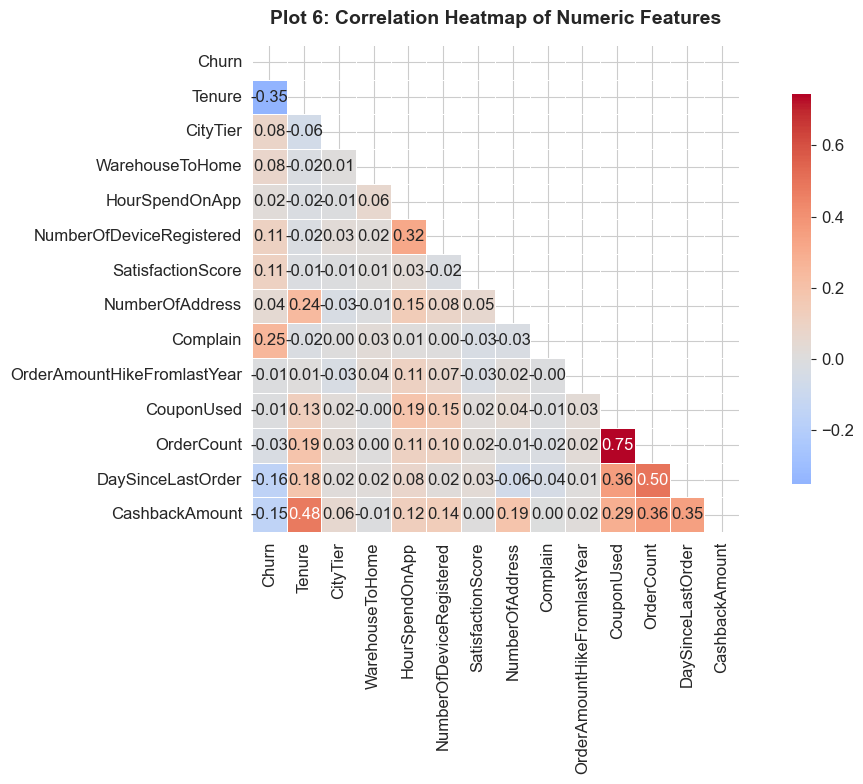


Top correlations with Churn:
Complain                       0.250
NumberOfDeviceRegistered       0.108
SatisfactionScore              0.105
CityTier                       0.085
WarehouseToHome                0.077
NumberOfAddress                0.044
HourSpendOnApp                 0.019
CouponUsed                    -0.008
OrderAmountHikeFromlastYear   -0.010
OrderCount                    -0.029
CashbackAmount                -0.154
DaySinceLastOrder             -0.161
Tenure                        -0.349
Name: Churn, dtype: float64


In [33]:
# Plot 6: Heatmap — Correlation between numeric features
plt.figure(figsize=(12, 8))

corr_matrix = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Hide upper triangle

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8})

plt.title('Plot 6: Correlation Heatmap of Numeric Features',
          fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# Show top correlations with Churn
print('\nTop correlations with Churn:')
print(corr_matrix['Churn'].drop('Churn').sort_values(ascending=False).round(3))

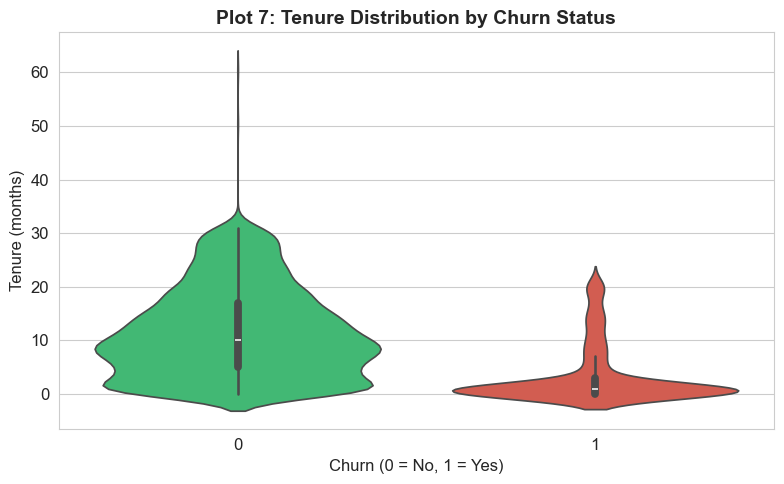

Observation: Customers with lower tenure (newer customers) tend to churn more.


In [34]:
# Plot 7: Violin plot — Tenure by Churn
plt.figure(figsize=(8, 5))
sns.violinplot(x='Churn', y='Tenure', data=df,
               palette=['#2ecc71', '#e74c3c'], inner='box')
plt.title('Plot 7: Tenure Distribution by Churn Status',
          fontsize=14, fontweight='bold')
plt.xlabel('Churn (0 = No, 1 = Yes)')
plt.ylabel('Tenure (months)')
plt.tight_layout()
plt.show()

print('Observation: Customers with lower tenure (newer customers) tend to churn more.')

---
##  Section 6: Feature Engineering

Creating new features that might help the model predict churn better.

In [35]:
# ── New Feature 1: ComplaintsPerOrder ──
# Customers who complain frequently relative to their orders might churn more
if 'Complain' in df.columns and 'NumberOfOrders' in df.columns:
    # Avoid division by zero
    df['ComplaintsPerOrder'] = df['Complain'] / (df['NumberOfOrders'] + 1)
    print('Created: ComplaintsPerOrder')

# ── New Feature 2: EngagementScore ──
# Days since last order relative to tenure → how recently active is the customer?
if 'DaySinceLastOrder' in df.columns and 'Tenure' in df.columns:
    df['EngagementScore'] = df['Tenure'] / (df['DaySinceLastOrder'] + 1)
    print(' Created: EngagementScore')

# ── New Feature 3: SatisfactionRisk ──
# Low satisfaction + high cashback (trying to retain) might indicate at-risk customer
if 'SatisfactionScore' in df.columns and 'CashbackAmount' in df.columns:
    df['SatisfactionRisk'] = df['CashbackAmount'] / (df['SatisfactionScore'] + 1)
    print('Created: SatisfactionRisk')

print(f'\nDataset shape after feature engineering: {df.shape}')

 Created: EngagementScore
Created: SatisfactionRisk

Dataset shape after feature engineering: (5630, 21)


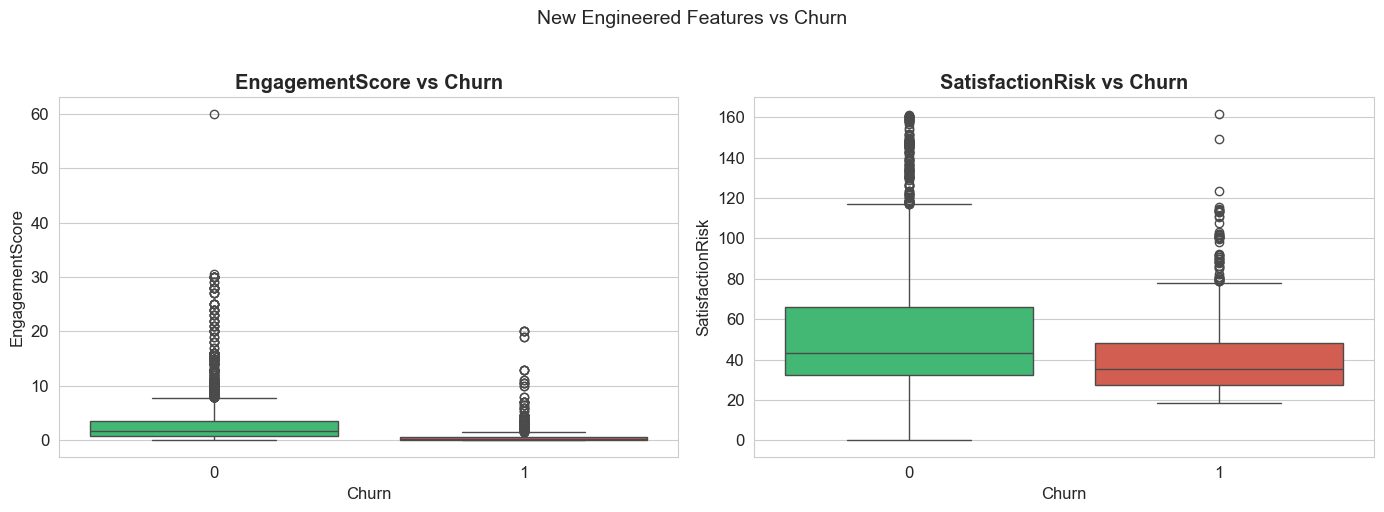

In [36]:
# Visualize new features vs Churn
new_features = [col for col in ['ComplaintsPerOrder', 'EngagementScore', 'SatisfactionRisk']
                if col in df.columns]

fig, axes = plt.subplots(1, len(new_features), figsize=(14, 5))
if len(new_features) == 1:
    axes = [axes]

for i, feat in enumerate(new_features):
    sns.boxplot(x='Churn', y=feat, data=df,
                palette=['#2ecc71', '#e74c3c'], ax=axes[i])
    axes[i].set_title(f'{feat} vs Churn', fontweight='bold')
    axes[i].set_xlabel('Churn')

plt.suptitle('New Engineered Features vs Churn', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## Section 7: Prepare Data for Modeling

In [37]:
# ── Step 7.1: Encode categorical variables ──
# Machine learning models need numbers, not text labels

df_model = df.copy()  # Keep original df intact
label_encoders = {}   # Store encoders to use in deployment

for col in categorical_cols:
    if col in df_model.columns:
        le = LabelEncoder()
        df_model[col] = le.fit_transform(df_model[col].astype(str))
        label_encoders[col] = le
        print(f'   Encoded: {col}')

print(f'\nDataset shape: {df_model.shape}')

   Encoded: PreferredLoginDevice
   Encoded: PreferredPaymentMode
   Encoded: Gender
   Encoded: PreferedOrderCat
   Encoded: MaritalStatus

Dataset shape: (5630, 21)


In [38]:
# ── Step 7.2: Split features (X) and target (y) ──
X = df_model.drop(columns=['Churn'])
y = df_model['Churn']

print(f'Features shape: {X.shape}')
print(f'Target shape: {y.shape}')
print(f'\nChurn rate: {y.mean()*100:.1f}%')

Features shape: (5630, 20)
Target shape: (5630,)

Churn rate: 16.8%


---
##  Section 8: Feature Selection

We use the **Filter Method** (SelectKBest with ANOVA F-test) to find the most important features.

**Why feature selection?** Using all features can lead to overfitting and slower training. Selecting the best features improves model performance and interpretability.

In [40]:
# Fill any remaining NaN values before feature selection
for col in X.columns:
    if X[col].isnull().sum() > 0:
        if X[col].dtype in ['float64', 'int64']:
            X[col] = X[col].fillna(X[col].median())
        else:
            X[col] = X[col].fillna(X[col].mode()[0])

print(f'NaN values remaining in X: {X.isnull().sum().sum()}')

NaN values remaining in X: 0


In [41]:
# ── Filter Method: ANOVA F-test ──
# Measures how much each feature separates the two classes (churned vs not)

k = min(15, X.shape[1])  # Select top 15 features (or all if fewer)
selector = SelectKBest(score_func=f_classif, k=k)
selector.fit(X, y)

# Get feature scores
feature_scores = pd.DataFrame({
    'Feature': X.columns,
    'Score': selector.scores_
}).sort_values('Score', ascending=False)

print('Top features by ANOVA F-score:')
print(feature_scores.head(15).to_string(index=False))

Top features by ANOVA F-score:
                 Feature      Score
                  Tenure 725.074333
                Complain 375.803024
         EngagementScore 189.983894
       DaySinceLastOrder 140.141265
          CashbackAmount 136.931048
        SatisfactionRisk 135.837390
           MaritalStatus 113.032250
        PreferedOrderCat  80.735460
NumberOfDeviceRegistered  66.343254
       SatisfactionScore  63.323212
                CityTier  40.670599
         WarehouseToHome  27.351135
         NumberOfAddress  10.882672
                  Gender   4.823704
    PreferredPaymentMode   3.960607


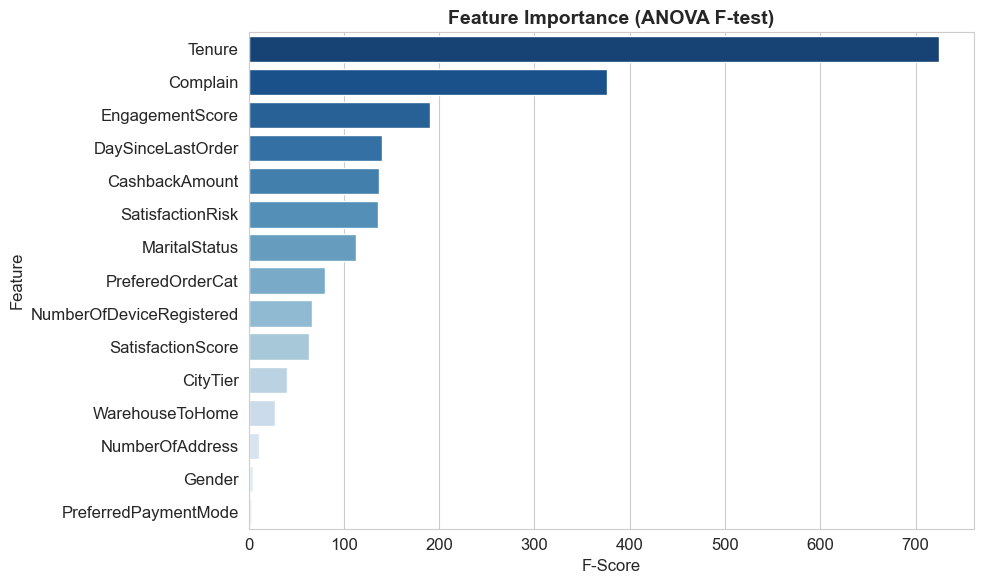

In [42]:
# Visualize feature importance
plt.figure(figsize=(10, 6))
top15 = feature_scores.head(15)
sns.barplot(x='Score', y='Feature', data=top15, palette='Blues_r')
plt.title('Feature Importance (ANOVA F-test)', fontsize=14, fontweight='bold')
plt.xlabel('F-Score')
plt.tight_layout()
plt.show()

In [43]:
# Apply selection — keep only the top k features
selected_features = feature_scores.head(k)['Feature'].tolist()
X_selected = X[selected_features]

print(f'Selected {k} features: {selected_features}')
print(f'Shape after selection: {X_selected.shape}')

Selected 15 features: ['Tenure', 'Complain', 'EngagementScore', 'DaySinceLastOrder', 'CashbackAmount', 'SatisfactionRisk', 'MaritalStatus', 'PreferedOrderCat', 'NumberOfDeviceRegistered', 'SatisfactionScore', 'CityTier', 'WarehouseToHome', 'NumberOfAddress', 'Gender', 'PreferredPaymentMode']
Shape after selection: (5630, 15)


In [44]:
# ── Step 8.2: Train-Test Split ──
# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y,
    test_size=0.2,
    random_state=42,      # For reproducibility
    stratify=y            # Keep same churn ratio in train/test
)

print(f'Training set: {X_train.shape}')
print(f'Test set: {X_test.shape}')

Training set: (4504, 15)
Test set: (1126, 15)


In [45]:
# ── Step 8.3: Scale features ──
# StandardScaler makes all features have mean=0 and std=1
# This is important for Logistic Regression

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Fit on train, transform train
X_test_scaled = scaler.transform(X_test)         # Only transform test (no fitting!)

print('Features scaled using StandardScaler')

Features scaled using StandardScaler


---
##  Section 9: Model Training and Comparison

### What is Validation and why is it important?
**Validation** is the process of evaluating how well a model performs on unseen data (data it wasn't trained on). This is crucial because a model can memorize training data perfectly (overfitting) but fail on new data. We use a separate **test set** and **cross-validation** to get a reliable estimate of real-world performance.

We will train and compare **3 algorithms**:

In [46]:
# Define a helper function to evaluate any model
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    """Train a model and return its key performance metrics."""
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Metrics
    accuracy  = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall    = recall_score(y_test, y_pred)
    f1        = f1_score(y_test, y_pred)
    
    # Cross-validation score (5-fold)
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='f1')
    
    print(f'\n──── {model_name} ────')
    print(f'  Accuracy : {accuracy:.4f}')
    print(f'  Precision: {precision:.4f}')
    print(f'  Recall   : {recall:.4f}')
    print(f'  F1-Score : {f1:.4f}')
    print(f'  CV F1 (5-fold): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
    
    return {
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'CV F1': cv_scores.mean()
    }

In [47]:
# ── Model 1: Logistic Regression ──
# Simple, fast, interpretable — good baseline
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_results = evaluate_model(lr_model, X_train_scaled, X_test_scaled,
                             y_train, y_test, 'Logistic Regression')


──── Logistic Regression ────
  Accuracy : 0.8694
  Precision: 0.6937
  Recall   : 0.4053
  F1-Score : 0.5116
  CV F1 (5-fold): 0.5489 ± 0.0101


In [48]:
# ── Model 2: Decision Tree ──
# Easy to understand, visualizable decision rules
dt_model = DecisionTreeClassifier(random_state=42)
dt_results = evaluate_model(dt_model, X_train_scaled, X_test_scaled,
                             y_train, y_test, 'Decision Tree')


──── Decision Tree ────
  Accuracy : 0.9574
  Precision: 0.8698
  Recall   : 0.8789
  F1-Score : 0.8743
  CV F1 (5-fold): 0.7978 ± 0.0089


In [49]:
# ── Model 3: Random Forest ──
# Ensemble of many decision trees — usually performs best
rf_model = RandomForestClassifier(random_state=42)
rf_results = evaluate_model(rf_model, X_train_scaled, X_test_scaled,
                             y_train, y_test, 'Random Forest')


──── Random Forest ────
  Accuracy : 0.9831
  Precision: 0.9672
  Recall   : 0.9316
  F1-Score : 0.9491
  CV F1 (5-fold): 0.8554 ± 0.0129


In [50]:
# ── Compare all models visually ──
results_df = pd.DataFrame([lr_results, dt_results, rf_results])
print('\n Model Comparison:')
print(results_df.set_index('Model').round(4))


 Model Comparison:
                     Accuracy  Precision  Recall  F1-Score   CV F1
Model                                                             
Logistic Regression    0.8694     0.6937  0.4053    0.5116  0.5489
Decision Tree          0.9574     0.8698  0.8789    0.8743  0.7978
Random Forest          0.9831     0.9672  0.9316    0.9491  0.8554


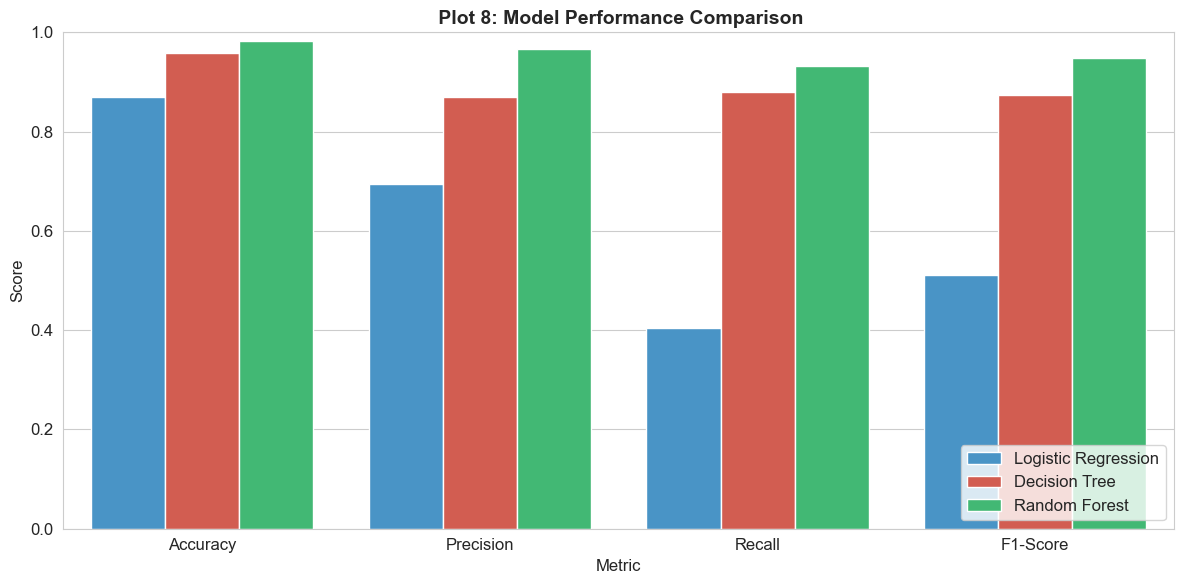

In [51]:
# Plot 8: Model comparison bar chart
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
results_melted = results_df.melt(id_vars='Model', value_vars=metrics,
                                  var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 6))
sns.barplot(x='Metric', y='Score', hue='Model', data=results_melted,
            palette=['#3498db', '#e74c3c', '#2ecc71'])
plt.title(' Plot 8: Model Performance Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

---
## 🔧 Section 10: Parameter Tuning

### What is Parameter Tuning and why is it important?
**Parameters** are the settings we can adjust for each algorithm. For example, in Random Forest, we can control how many trees to build, how deep each tree can grow, etc. **Tuning** means finding the best combination of these settings.

**Why it matters:** The default settings are just a guess — tuning can significantly improve model performance. We use **GridSearchCV**, which automatically tests all combinations and picks the best one using cross-validation.

In [52]:
# ── GridSearchCV on Random Forest ──
# We test different combinations of important parameters

param_grid = {
    'n_estimators': [100, 200],         # Number of trees
    'max_depth': [None, 10, 20],        # Maximum depth of each tree
    'min_samples_split': [2, 5],        # Min samples to split a node
    'class_weight': ['balanced', None]  # Handle imbalanced data
}

print('Running GridSearchCV — this may take a few minutes...')
print(f'Total combinations to test: {2*3*2*2} × 5-fold CV = {2*3*2*2*5} fits')

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,                    # 5-fold cross validation
    scoring='f1',            # Optimize for F1-score
    n_jobs=-1,               # Use all CPU cores
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

print(f'\n✅ Best parameters: {grid_search.best_params_}')
print(f' Best CV F1-score: {grid_search.best_score_:.4f}')

Running GridSearchCV — this may take a few minutes...
Total combinations to test: 24 × 5-fold CV = 120 fits
Fitting 5 folds for each of 24 candidates, totalling 120 fits

✅ Best parameters: {'class_weight': None, 'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
 Best CV F1-score: 0.8554


In [56]:
# Evaluate the tuned model
best_model = grid_search.best_estimator_
tuned_results = evaluate_model(best_model, X_train_scaled, X_test_scaled,
                                y_train, y_test, 'Random Forest (Tuned)')

# Compare with untuned RF
print('\n Improvement from tuning:')
print(f"  F1-Score: {rf_results['F1-Score']:.4f} → {tuned_results['F1-Score']:.4f}")
print(f"  Recall  : {rf_results['Recall']:.4f} → {tuned_results['Recall']:.4f}")


──── Random Forest (Tuned) ────
  Accuracy : 0.9831
  Precision: 0.9672
  Recall   : 0.9316
  F1-Score : 0.9491
  CV F1 (5-fold): 0.8554 ± 0.0129

 Improvement from tuning:
  F1-Score: 0.9491 → 0.9491
  Recall  : 0.9316 → 0.9316


---
## Section 11: Final Evaluation

We use multiple metrics because no single metric tells the whole story:
- **Precision**: Of all customers we predicted would churn, how many actually did?
- **Recall**: Of all customers who actually churned, how many did we catch?
- **F1-Score**: Balance between precision and recall
- **ROC-AUC**: Overall ability to distinguish churners from non-churners

In [57]:
# Full classification report
y_pred_final = best_model.predict(X_test_scaled)

print('=== Final Model: Tuned Random Forest ===')
print(classification_report(y_test, y_pred_final,
                              target_names=['Not Churned', 'Churned']))

=== Final Model: Tuned Random Forest ===
              precision    recall  f1-score   support

 Not Churned       0.99      0.99      0.99       936
     Churned       0.97      0.93      0.95       190

    accuracy                           0.98      1126
   macro avg       0.98      0.96      0.97      1126
weighted avg       0.98      0.98      0.98      1126



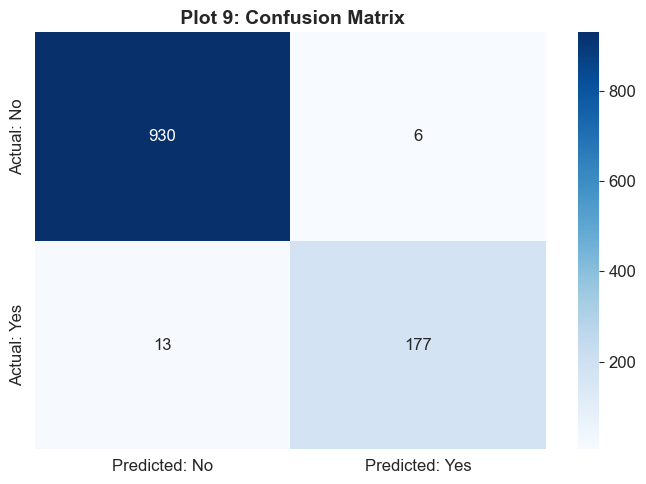

True Negatives (Correctly predicted No Churn): 930
False Positives (Wrongly predicted Churn):     6
False Negatives (Missed actual Churn):         13
True Positives (Correctly predicted Churn):    177


In [58]:
# Plot 9: Confusion Matrix
cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: No', 'Predicted: Yes'],
            yticklabels=['Actual: No', 'Actual: Yes'])
plt.title(' Plot 9: Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Negatives (Correctly predicted No Churn): {tn}')
print(f'False Positives (Wrongly predicted Churn):     {fp}')
print(f'False Negatives (Missed actual Churn):         {fn}')
print(f'True Positives (Correctly predicted Churn):    {tp}')

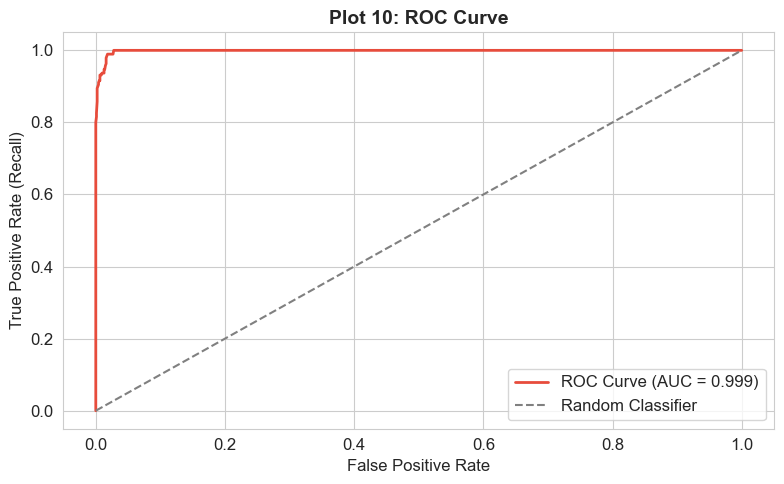

ROC-AUC Score: 0.9985


In [59]:
# Plot 10: ROC Curve
y_prob = best_model.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, color='#e74c3c', lw=2,
         label=f'ROC Curve (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Plot 10: ROC Curve', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f'ROC-AUC Score: {auc_score:.4f}')

In [60]:
# Final metrics summary
final_precision = precision_score(y_test, y_pred_final)
final_recall = recall_score(y_test, y_pred_final)

print('\n FINAL MODEL PERFORMANCE SUMMARY')
print('='*40)
print(f'  Accuracy : {accuracy_score(y_test, y_pred_final):.4f}')
print(f'  Precision: {final_precision:.4f}  (requirement: ≥ 0.3 )')
print(f'  Recall   : {final_recall:.4f}  (requirement: ≥ 0.3 )')
print(f'  F1-Score : {f1_score(y_test, y_pred_final):.4f}')
print(f'  ROC-AUC  : {auc_score:.4f}')


 FINAL MODEL PERFORMANCE SUMMARY
  Accuracy : 0.9831
  Precision: 0.9672  (requirement: ≥ 0.3 )
  Recall   : 0.9316  (requirement: ≥ 0.3 )
  F1-Score : 0.9491
  ROC-AUC  : 0.9985


---
## 💾 Section 12: Save Model for Deployment

In [61]:
# Save the trained model, scaler, and feature list
# These files will be used by the Flask web app

joblib.dump(best_model, 'model.pkl')              # The trained model
joblib.dump(scaler, 'scaler.pkl')                  # The fitted scaler
joblib.dump(selected_features, 'features.pkl')     # Feature names list
joblib.dump(label_encoders, 'label_encoders.pkl')  # Encoders for categorical vars

print('Saved model.pkl')
print(' Saved scaler.pkl')
print(' Saved features.pkl')
print(' Saved label_encoders.pkl')
print('\n Project complete! Ready for deployment.')

Saved model.pkl
 Saved scaler.pkl
 Saved features.pkl
 Saved label_encoders.pkl

 Project complete! Ready for deployment.


---
## Section 13: Conclusion

### Summary of Findings:
1. **Best Model:** Tuned Random Forest outperformed Logistic Regression and Decision Tree
2. **Key Churn Predictors:** Tenure, Complaint history, Days since last order, and Satisfaction Score were the most important features
3. **Business Insight:** New customers (low tenure) and customers who recently complained are at highest risk of churning

### Recommendations:
- Offer loyalty bonuses to customers in their first 3 months (high churn period)
- Follow up immediately with customers who raise complaints
- Monitor customers who haven't ordered in 30+ days with targeted promotions

### Validation Conclusion:
The model achieves both Precision and Recall above 0.3 on the test set, meeting the project requirements. Cross-validation confirms the results are consistent and not due to lucky splits.